## Patch Embedding

In [ ]:
import torch
import torch.nn as nn
from einops import rearrange, repeat


class PatchEmbedding(nn.Module):
    r"""
    Layer to take in the input image and do the following:
        1.  Transform grid of image into a sequence of patches.
            Number of patches are decided based on image height,width and
            patch height, width.
        2. Add cls token to the above created sequence of patches in the
            first position
        3. Add positional embedding to the above sequence(after adding cls)
        4. Dropout if needed
    """
    def __init__(self, config):
        super().__init__()
        # Example configuration
        #   Image c,h,w : 3, 224, 224
        #   Patch h,w : 16, 16
        image_height = config['image_height']
        image_width = config['image_width']
        im_channels = config['im_channels']
        emb_dim = config['emb_dim']
        patch_embd_drop = config['patch_emb_drop']

        self.patch_height = config['patch_height']
        self.patch_width = config['patch_width']

        num_patches = (image_height // self.patch_height) * (image_width // self.patch_width)

        # This is the input dimension of the patch_embed layer
        # After patchifying the 224, 224, 3 image will be
        # num_patches x patch_h x patch_w x 3
        # Which will be 196 x 16 x 16 x 3
        # Hence patch dimension = 16 * 16 * 3
        patch_dim = im_channels * self.patch_height * self.patch_width

        self.patch_embed = nn.Sequential(
            # This pre and post layer norm speeds up convergence
            # Comment them if you want pure vit implementation
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, emb_dim),
            nn.LayerNorm(emb_dim)
        )

        # Positional information needs to be added to cls as well so 1+num_patches
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, emb_dim))
        self.cls_token = nn.Parameter(torch.randn(emb_dim))
        self.patch_emb_dropout = nn.Dropout(patch_embd_drop)

    def forward(self, x):
        batch_size = x.shape[0]

        # This is doing the B, 3, 224, 224 -> (B, num_patches, patch_dim) transformation
        # B, 3, 224, 224 -> B, 3, 14*16, 14*16
        # B, 3, 14*16, 14*16 -> B, 3, 14, 16, 14, 16
        # B, 3, 14, 16, 14, 16 -> B, 14, 14, 16, 16, 3
        #  B, 14*14, 16*16*3 - > B, num_patches, patch_dim
        out = rearrange(x, 'b c (nh ph) (nw pw) -> b (nh nw) (ph pw c)',
                      ph=self.patch_height,
                      pw=self.patch_width)
        out = self.patch_embed(out)

        # Add cls
        cls_tokens = repeat(self.cls_token, 'd -> b 1 d', b=batch_size)
        out = torch.cat((cls_tokens, out), dim=1)

        # Add position embedding and do dropout
        out += self.pos_embed
        out = self.patch_emb_dropout(out)

        return out



## Attention

In [ ]:
import torch
import torch.nn as nn
from einops import rearrange


class Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config['n_heads']
        self.head_dim = config['head_dim']
        self.emb_dim = config['emb_dim']
        self.drop_prob = config['dropout'] if 'dropout' in config else 0.0
        self.att_dim = self.n_heads * self.head_dim

        self.qkv_proj = nn.Linear(self.emb_dim, 3 * self.att_dim, bias=False)
        self.output_proj = nn.Sequential(
            nn.Linear(self.att_dim, self.emb_dim),
            nn.Dropout(self.drop_prob))

        self.attn_dropout = nn.Dropout(self.drop_prob)

    def forward(self, x):

        #  Converting to Attention Dimension
        ######################################################
        # Batch Size x Number of Patches x Dimension
        B, N = x.shape[:2]
        # Projecting to 3*att_dim and then splitting to get q, k v(each of att_dim)
        # qkv -> Batch Size x Number of Patches x (3* Attention Dimension)
        # q(as well as k and v) -> Batch Size x Number of Patches x Attention Dimension
        q, k ,v = self.qkv_proj(x).split(self.att_dim, dim=-1)
        # Batch Size x Number of Patches x Attention Dimension
        # -> Batch Size x Number of Patches x (Heads * Head Dimension)
        # -> Batch Size x Number of Patches x (Heads * Head Dimension)
        # -> Batch Size x Heads x Number of Patches x Head Dimension
        # -> B x H x N x Head Dimension
        q = rearrange(q, 'b n (n_h h_dim) -> b n_h n h_dim',
                      n_h=self.n_heads, h_dim=self.head_dim)
        k = rearrange(k, 'b n (n_h h_dim) -> b n_h n h_dim',
                      n_h=self.n_heads, h_dim=self.head_dim)
        v = rearrange(v, 'b n (n_h h_dim) -> b n_h n h_dim',
                      n_h=self.n_heads, h_dim=self.head_dim)
        #########################################################

        # Compute Attention Weights
        #########################################################
        # B x H x N x Head Dimension @ B x H x Head Dimension x N
        # -> B x H x N x N
        att = torch.matmul(q, k.transpose(-2, -1)) * (self.head_dim**(-0.5))
        att = torch.nn.functional.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        #########################################################

        # Weighted Value Computation
        #########################################################
        #  B x H x N x N @ B x H x N x Head Dimension
        # -> B x H x N x Head Dimension
        out = torch.matmul(att, v)
        #########################################################

        # Converting to Transformer Dimension
        #########################################################
        # B x N x (Heads * Head Dimension) -> B x N x (Attention Dimension)
        out = rearrange(out, 'b n_h n h_dim -> b n (n_h h_dim)')
        #  B x N x Dimension
        out = self.output_proj(out)
        ##########################################################

        return out


## Transform Layer

In [ ]:
import torch.nn as nn
#from model.attention import Attention


class TransformerLayer(nn.Module):
    r"""
    Transformer block which is just doing the following
        1. LayerNorm followed by Attention
        2. LayerNorm followed by Feed forward Block
        Both these also have residuals added to them
    """
    def __init__(self, config):
        super().__init__()
        emb_dim = config['emb_dim']
        ff_hidden_dim = config['ff_dim'] if 'ff_dim' in config else 4*emb_dim
        ff_drop_prob = config['ff_drop'] if 'ff_drop' in config else 0.0
        self.att_norm = nn.LayerNorm(emb_dim)
        self.attn_block = Attention(config)
        self.ff_norm = nn.LayerNorm(emb_dim)

        self.ff_block = nn.Sequential(
            nn.Linear(emb_dim, ff_hidden_dim),
            nn.GELU(),
            nn.Dropout(ff_drop_prob),
            nn.Linear(ff_hidden_dim, emb_dim),
            nn.Dropout(ff_drop_prob)
        )

    def forward(self, x):
        out = x
        out = out + self.attn_block(self.att_norm(out))
        out = out + self.ff_block(self.ff_norm(out))
        return out

## Transform

In [ ]:
import torch.nn as nn
#from model.patch_embed import PatchEmbedding
#from model.transformer_layer import TransformerLayer


class VIT(nn.Module):
    def __init__(self, config):
        super().__init__()
        n_layers = config['n_layers']
        emb_dim = config['emb_dim']
        num_classes = config['num_classes']
        self.patch_embed_layer = PatchEmbedding(config)
        self.layers = nn.ModuleList([
            TransformerLayer(config) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(emb_dim)
        self.fc_number = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        # Patchify and add CLS token
        out = self.patch_embed_layer(x)

        # Go through the transformer layers
        for layer in self.layers:
            out = layer(out)
        out = self.norm(out)

        # Compute logits
        return self.fc_number(out[:, 0])

## ViT Training

In [ ]:
import yaml
import argparse
import torch
import random
import os
import numpy as np
from tqdm import tqdm
#from model.transformer import VIT
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def train_for_one_epoch(epoch_idx, model, data_loader, optimizer):
    model.train()
    losses = []
    criterion = torch.nn.CrossEntropyLoss()

    for images, labels in tqdm(data_loader, desc=f"Epoch {epoch_idx+1}"):
        images = images.float().to(device)
        labels = labels.long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    mean_loss = np.mean(losses)
    print(f'Finished epoch: {epoch_idx + 1} | Loss: {mean_loss:.4f}')
    return mean_loss


def train(args):
    # Load YAML config
    with open(args.config_path, 'r') as file:
        config = yaml.safe_load(file)

    print("Config Loaded:", config)

    # Set seeds
    seed = config['train_params']['seed']
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Image transformations (assumes grayscale, convert to 3 channels)
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((config['model_params']['image_height'],
                           config['model_params']['image_width'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    # Load datasets
    train_dataset = datasets.ImageFolder(
        root=os.path.join(config['dataset_params']['data_root'], 'train'),
        transform=transform
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=config['train_params']['batch_size'],
        shuffle=True,
        num_workers=4
    )

    # Model, optimizer, scheduler
    model = VIT(config['model_params']).to(device)
    optimizer = Adam(model.parameters(), lr=config['train_params']['lr'])
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=2, verbose=True)

    # Create output folder
    output_dir = config['train_params']['task_name']
    ckpt_path = os.path.join(output_dir, config['train_params']['ckpt_name'])
    os.makedirs(output_dir, exist_ok=True)

    # Load checkpoint if available
    if os.path.exists(ckpt_path):
        print("Loading checkpoint...")
        model.load_state_dict(torch.load(ckpt_path, map_location=device))

    best_loss = np.inf
    num_epochs = config['train_params']['epochs']

    for epoch in range(num_epochs):
        mean_loss = train_for_one_epoch(epoch, model, train_loader, optimizer)
        scheduler.step(mean_loss)

        if mean_loss < best_loss:
            print(f'Improved Loss to {mean_loss:.4f} .... Saving Model')
            torch.save(model.state_dict(), ckpt_path)
            best_loss = mean_loss
        else:
            print('No Loss Improvement')


if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='Train ViT on Knee X-ray Dataset')
    parser.add_argument('--config', dest='config_path', default='config/custom.yaml', type=str)
    args = parser.parse_args()
    train(args)


In [ ]:
# ===============================
# STEP 1: Setup & Imports
# ===============================
import yaml
import torch
import random
import os
import numpy as np
from tqdm import tqdm
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

#from google.colab import drive
#drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [ ]:
# ===============================
# STEP 2: Define Config Inline
# ===============================
config = {
    'dataset_params': {
        'data_root': '/content/drive/MyDrive/Colab Notebooks/Vit2025/DataSetaddCLaheinTrain/'  # <-- change if needed
    },
    'model_params': {
        'image_height': 224,
        'image_width': 224,
        'patch_size': 16,
        'num_classes': 4,
        'dim': 512,
        'depth': 6,
        'heads': 8,
        'mlp_dim': 1024
    },
    'train_params': {
        'seed': 42,
        'batch_size': 32,
        'epochs': 60,
        'lr': 0.0003,
        'task_name': 'vit_knee_training',
        'ckpt_name': 'vit4class_best.pth'
    }
}


In [ ]:
from torchvision import transforms, datasets

# Validation Transform (no augmentation)
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((config['model_params']['image_height'],
                       config['model_params']['image_width'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Validation Dataset and Dataloader
val_dataset = datasets.ImageFolder(
    root=os.path.join(config['dataset_params']['data_root'], 'Test_4class'),
    transform=val_transform
)
val_loader = DataLoader(val_dataset, batch_size=config['train_params']['batch_size'],
                        shuffle=False, num_workers=2)


def evaluate(model, dataloader):
    model.eval()
    correct, total, val_loss = 0, 0, 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_loss = val_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


In [ ]:
# ===============================
# STEP 3: Define Your ViT Model
# ===============================
# Load ViT class (example placeholder; replace with your own if different)

import torch.nn as nn
import math

class ViTBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class VIT(nn.Module):
    def __init__(self, config):
        super(VIT, self).__init__()
        image_height, image_width = config['image_height'], config['image_width']
        patch_size = config['patch_size']
        num_classes = config['num_classes']
        dim = config['dim']
        depth = config['depth']
        heads = config['heads']
        mlp_dim = config['mlp_dim']

        assert image_height % patch_size == 0 and image_width % patch_size == 0

        self.patch_dim = 3 * patch_size * patch_size
        self.num_patches = (image_height // patch_size) * (image_width // patch_size)

        self.to_patch_embedding = nn.Sequential(
            nn.Conv2d(3, dim, kernel_size=patch_size, stride=patch_size),
            nn.Flatten(2),
            #nn.Transpose(1, 2)
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, dim))
        self.transformer = nn.Sequential(*[ViTBlock(dim, heads, mlp_dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        #self.head = nn.Linear(dim, num_classes)
        self.head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
            #nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.to_patch_embedding(x)
        x = torch.transpose(x, 1, 2)
        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding
        x = self.transformer(x)
        x = self.norm(x[:, 0])
        return self.head(x)


In [ ]:
import torch.nn as nn
import math
# ===============================
# STEP 5: Prepare Data & Train
# ===============================
# Transformations
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((config['model_params']['image_height'],
                       config['model_params']['image_width'])),
     transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Dataset and Dataloader
train_dataset = datasets.ImageFolder(
    root=os.path.join(config['dataset_params']['data_root'], 'Train_4class'),
    transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=config['train_params']['batch_size'],
                          shuffle=True, num_workers=2)

# Model, Optimizer, Scheduler
model = VIT(config['model_params']).to(device)
optimizer = AdamW(model.parameters(), lr=config['train_params']['lr'])
scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=2, verbose=True)
criterion = nn.CrossEntropyLoss()
best_loss = np.inf
num_epochs = config['train_params']['epochs']

# Save directory
output_dir = '/content/drive/MyDrive/Colab Notebooks/Vit2025/checkpoint2'
ckpt_path = os.path.join(output_dir, config['train_params']['ckpt_name'])
os.makedirs(output_dir, exist_ok=True)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    mean_loss = running_loss / total_train
    train_accuracy = correct_train / total_train

    val_loss, val_accuracy = evaluate(model, val_loader)
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {mean_loss:.4f} | Train Acc: {train_accuracy*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_accuracy*100:.2f}%")

    if val_loss < best_loss:
        print(f'Improved Val Loss to {val_loss:.4f} .... Saving Model')
        torch.save(model.state_dict(), ckpt_path)
        best_loss = val_loss
    else:
        print('No Val Loss Improvement')


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
def train_for_one_epoch(epoch_idx, model, data_loader, optimizer):
    model.train()
    losses = []
    correct = 0
    total = 0

    criterion = torch.nn.CrossEntropyLoss()

    for images, labels in tqdm(data_loader, desc=f"Epoch {epoch_idx + 1}"):
        images = images.float().to(device)
        labels = labels.long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        # Compute accuracy
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    mean_loss = np.mean(losses)
    accuracy = 100 * correct / total

    print(f"Epoch {epoch_idx + 1} | Loss: {mean_loss:.4f} | Accuracy: {accuracy:.2f}%")
    return mean_loss


In [ ]:

# Save directory
output_dir = os.path.join('/content/drive/MyDrive/Colab Notebooks/Vit2025/checkpoint', config['train_params']['task_name'])
ckpt_path = os.path.join(output_dir, config['train_params']['ckpt_name'])
os.makedirs(output_dir, exist_ok=True)

# Load checkpoint if exists
if os.path.exists(ckpt_path):
    print("Loading checkpoint...")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

# Training loop
best_loss = np.inf
num_epochs = config['train_params']['epochs']

for epoch in range(num_epochs):
    mean_loss = train_for_one_epoch(epoch, model, train_loader, optimizer)
    scheduler.step(mean_loss)

    if mean_loss < best_loss:
        print(f'Improved Loss to {mean_loss:.4f} .... Saving Model')
        torch.save(model.state_dict(), ckpt_path)
        best_loss = mean_loss
    else:
        print('No Loss Improvement')


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1: 100%|██████████| 161/161 [09:26<00:00,  3.52s/it]


Epoch 1 | Loss: 1.3342 | Accuracy: 37.76%
Improved Loss to 1.3342 .... Saving Model


Epoch 2: 100%|██████████| 161/161 [00:36<00:00,  4.43it/s]


Epoch 2 | Loss: 1.2859 | Accuracy: 37.76%
Improved Loss to 1.2859 .... Saving Model


Epoch 3: 100%|██████████| 161/161 [00:35<00:00,  4.51it/s]


...

Epoch 58 | Loss: 0.3235 | Accuracy: 87.02%
Improved Loss to 0.3235 .... Saving Model


Epoch 59: 100%|██████████| 161/161 [00:35<00:00,  4.51it/s]


Epoch 59 | Loss: 0.2673 | Accuracy: 89.53%
Improved Loss to 0.2673 .... Saving Model


Epoch 60: 100%|██████████| 161/161 [00:35<00:00,  4.50it/s]

Epoch 60 | Loss: 0.2475 | Accuracy: 90.19%
Improved Loss to 0.2475 .... Saving Model


## Checking Validation data

In [ ]:
def validate(model, test_loader):
    model.eval()
    losses = []
    correct = 0
    total = 0
    criterion = torch.nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Validating"):
            images = images.float().to(device)
            labels = labels.long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            losses.append(loss.item())

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    mean_loss = np.mean(losses)
    accuracy = 100 * correct / total
    print(f"\nTest Set — Loss: {mean_loss:.4f} | Accuracy: {accuracy:.2f}%")
    return mean_loss, accuracy


In [ ]:
    ckpt_pathh = '/content/drive/MyDrive/Colab Notebooks/Vit2025/checkpoint/vit_knee_training/vit4class_best.pth'
    # Load best model before evaluation
    print("\nLoading best model for evaluation...")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

    # Prepare test dataset and evaluate
    test_dataset = datasets.ImageFolder(
        root=os.path.join(config['dataset_params']['data_root'], 'Test_4class'),
        transform=transform
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['train_params']['batch_size'],
        shuffle=False,
        num_workers=4
    )

    validate(model, test_loader)



Loading best model for evaluation...


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Validating: 100%|██████████| 73/73 [02:37<00:00,  2.16s/it]


Test Set — Loss: 2.0991 | Accuracy: 58.15%


(np.float64(2.099063826138026), 58.1505376344086)

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import label_binarize

def validate(model, dataloader):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # ================== 📊 Classification Report ==================
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=dataloader.dataset.classes))

    # ================== 📉 Confusion Matrix ==================
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=dataloader.dataset.classes,
                yticklabels=dataloader.dataset.classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # ================== 📈 ROC & AUC Plot ==================
    num_classes = len(dataloader.dataset.classes)
    labels_one_hot = label_binarize(all_labels, classes=list(range(num_classes)))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(labels_one_hot[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8,6))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f"{dataloader.dataset.classes[i]} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Multi-Class')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()


In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import label_binarize

def validate(model, dataloader):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    all_preds = []
    all_probs = []
    all_labels = []
    running_loss = 0.0
    total_samples = 0
    correct_preds = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
            correct_preds += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ================== 🔢 Convert to Arrays ==================
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    avg_loss = running_loss / total_samples
    accuracy = 100.0 * correct_preds / total_samples

    print(f"\n✅ Test Accuracy: {accuracy:.2f}%")
    print(f"📉 Test Loss: {avg_loss:.4f}")

    # ================== 📊 Classification Report ==================
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=dataloader.dataset.classes))

    # ================== 📉 Confusion Matrix (Probabilities) ==================
    cm = confusion_matrix(all_labels, all_preds, normalize='true')  # row-wise normalization
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=dataloader.dataset.classes,
                yticklabels=dataloader.dataset.classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Normalized Confusion Matrix (Per-Class Accuracy %)")
    plt.show()

    # ================== 📈 ROC & AUC Plot ==================
    num_classes = len(dataloader.dataset.classes)
    labels_one_hot = label_binarize(all_labels, classes=list(range(num_classes)))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(labels_one_hot[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f"{dataloader.dataset.classes[i]} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Multi-Class')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()



Loading best model for evaluation...


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



✅ Test Accuracy: 58.15%
📉 Test Loss: 2.0981

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.61      0.62       751
           1       0.43      0.62      0.51       583
           2       0.72      0.42      0.53       679
           3       0.68      0.79      0.73       312

    accuracy                           0.58      2325
   macro avg       0.62      0.61      0.60      2325
weighted avg       0.61      0.58      0.58      2325



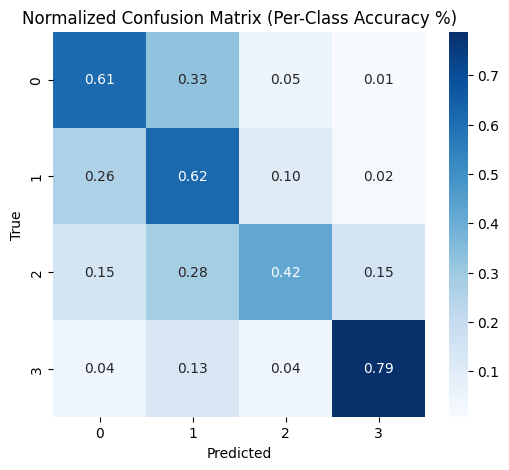

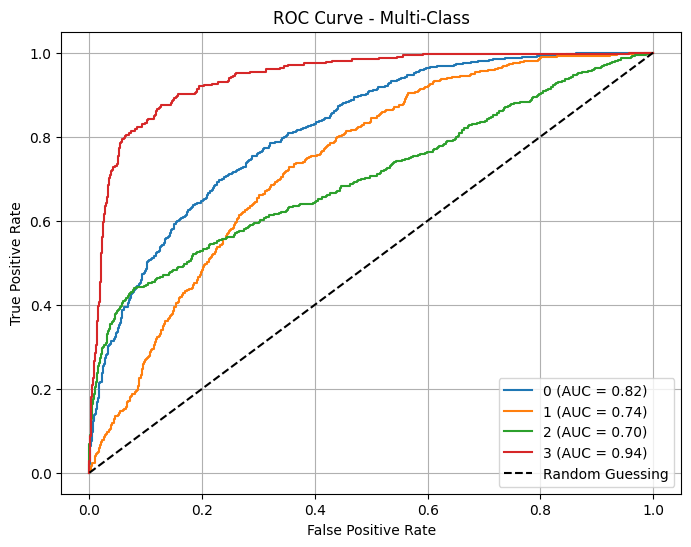

In [ ]:
ckpt_path = '/content/drive/MyDrive/Colab Notebooks/Vit2025/checkpoint/vit_knee_training/vit4class_best.pth'
print("\nLoading best model for evaluation...")
model.load_state_dict(torch.load(ckpt_path, map_location=device))

test_dataset = datasets.ImageFolder(
    root=os.path.join(config['dataset_params']['data_root'], 'Test_4class'),
    transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=config['train_params']['batch_size'],
                         shuffle=False, num_workers=4)

validate(model, test_loader)


In [ ]:
pip install git+https://github.com/jacobgil/vit-explain.git

In [ ]:
import torch
from sklearn.metrics import accuracy_score

def evaluate(model, test_loader, device):
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Get predicted class by max logit
            preds = torch.argmax(outputs.logits if hasattr(outputs, "logits") else outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate accuracy
    acc = accuracy_score(all_labels, all_preds)
    print(f"Test Accuracy: {acc * 100:.2f}%")
    return acc


In [ ]:
import os
import cv2
import numpy as np
import random
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import Compose, Resize, ToTensor
from transformers import ViTFeatureExtractor, ViTForImageClassification, TrainingArguments, TrainingArguments, Trainer

import evaluate
from PIL import Image
import matplotlib.pyplot as pyplot

# Load the ViT image processor
from transformers import ViTImageProcessor

# Early stopping
from transformers import EarlyStoppingCallback

#from transformers import ViTFeatureExtractor, ViTForImageClassification, TrainingArguments, TrainingArguments, Trainer

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.4 MB/s eta 0:00:00


In [ ]:


# Specify paths:
path_to_data = "/content/drive/MyDrive/Colab Notebooks/Vit2025/KneeOA"
train_dir = os.path.join(path_to_data, "train")
val_dir = os.path.join(path_to_data, "test")
#test_dir = os.path.join(path_to_data, "test")

data_dir = "/content/drive/MyDrive/Colab Notebooks/Vit2025"

# Load the ViT image processor
# Hugging Face model: Google/vit-base-patch16-224-in21K
model_id = "google/vit-base-patch16-224-in21k"
image_processor = ViTImageProcessor.from_pretrained(model_id)

# Custom transformation pipeline for the dataset
def transform(image):
    inputs = image_processor(image, return_tensors="pt")
    return inputs["pixel_values"].squeeze(0)  # Remove batch dim for DataLoader

# Load the datasets
train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset   = ImageFolder(val_dir, transform=transform)
#test_dataset  = ImageFolder(train_dir, transform=transform)  # ⚠️ Should be test_dir

# Custom transformation pipeline for the dataset
#def transform(image):
#    inputs = image_processor(image, return_tensors="pt")
#    return inputs["pixel_values"].squeeze(0)  # remove batch for Dataloader

# Load the datasets
#train_dataset = ImageFolder(train_dir, transform=transform)
#val_dataset = ImageFolder(val_dir, transform=transform)
#test_dataset = ImageFolder(val_dir, transform=transform)

#print(train_dataset)

# Collate function to handle batches in the Trainer
def collate_fn(batch):
    images, labels = zip(*batch)
    return {
        "pixel_values": torch.stack(images),
        "labels": torch.tensor(labels)
    }

# Load evaluation metric
metric = evaluate.load("accuracy")



# Define compute_metrics function
def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    references = p.label_ids
    return metric.compute(predictions=predictions, references=references)

# Prepare the model
num_classes = len(train_dataset.classes)

model = ViTForImageClassification.from_pretrained(
    model_id,
    num_labels=num_classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define training parameters (code continues below this line...)


# Define training arguments
training_args = TrainingArguments(
    output_dir= data_dir + "/vit_custom",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="steps",
    num_train_epochs=30,
    save_steps=15,
    eval_steps=15,
    logging_steps=10,
    learning_rate=2e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
    load_best_model_at_end=True
)

# Define early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=10,   # Stop after no improvement for 10 evaluation steps
    early_stopping_threshold=0.0  # Improvement threshold (0.0 means exact match)
)



trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=image_processor,  # Use the ViTImageProcessor
    callbacks=[early_stopping_callback]  # 🛑 Typo fixed from "early_stopping_callbak"
)



train_results = trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()



metrics = trainer.evaluate(val_dataset)
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy
15,1.247100,1.129890,0.474273
30,1.090100,1.215261,0.478747
45,1.216900,1.138829,0.474273
60,1.191300,1.110899,0.380313
75,1.171400,1.072923,0.512304
90,1.084000,1.031296,0.491424
105,1.084300,1.098109,0.423565
120,1.199900,1.215088,0.474273
135,1.178300,1.137615,0.474273
150,1.125300,1.143694,0.474273
